['../results/2025-07-11/19/000006597-AbsorptionImageExpFrag.h5', '../results/2025-07-11/19/000006598-AbsorptionImageExpFrag.h5']
File 1: ../results/2025-07-11/19/000006597-AbsorptionImageExpFrag.h5
File 2: ../results/2025-07-11/19/000006598-AbsorptionImageExpFrag.h5


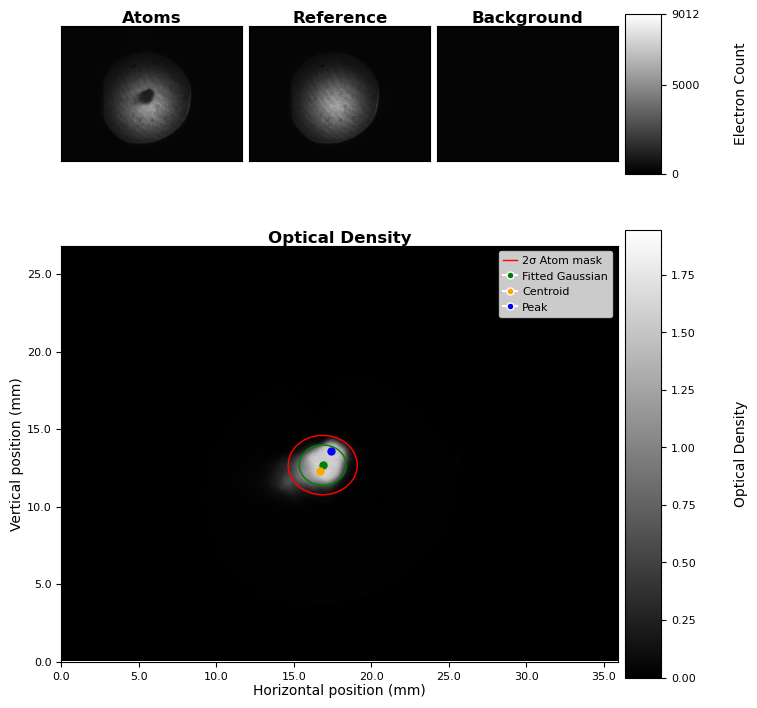

<KeysViewHDF5 ['Images.All.0', 'Images.All.1', 'Images.All.10', 'Images.All.11', 'Images.All.12', 'Images.All.13', 'Images.All.14', 'Images.All.15', 'Images.All.16', 'Images.All.17', 'Images.All.18', 'Images.All.19', 'Images.All.2', 'Images.All.20', 'Images.All.21', 'Images.All.22', 'Images.All.23', 'Images.All.24', 'Images.All.25', 'Images.All.26', 'Images.All.27', 'Images.All.28', 'Images.All.29', 'Images.All.3', 'Images.All.30', 'Images.All.31', 'Images.All.32', 'Images.All.33', 'Images.All.34', 'Images.All.35', 'Images.All.36', 'Images.All.37', 'Images.All.38', 'Images.All.39', 'Images.All.4', 'Images.All.40', 'Images.All.41', 'Images.All.42', 'Images.All.43', 'Images.All.44', 'Images.All.45', 'Images.All.46', 'Images.All.47', 'Images.All.48', 'Images.All.49', 'Images.All.5', 'Images.All.50', 'Images.All.51', 'Images.All.52', 'Images.All.53', 'Images.All.54', 'Images.All.55', 'Images.All.56', 'Images.All.57', 'Images.All.58', 'Images.All.59', 'Images.All.6', 'Images.All.60', 'Image

In [141]:
import h5py
from sipyco import pyon
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
import os as os
import sys
sys.path.append('/home/ae19663/artiq')  # Adjust this path to the parent directory of 'repository'
from repository.imaging.processor import AbsImage  # noqa: E402


# it will take folder(scan path) path as input and return sorted list of h5 files DIRECTORY
# the files are sorted based on the numeric part of their names, which is before the first hyphen '-'.
# For example, if the files are named like "000001234-AbsorptionImageExpFrag.h5",
# the sorting will be based on the numeric part "000001234".

def sorted_files(directory):
    """
    Sort files in the given directory based on the numeric part of their names.
    """
    files = os.listdir(directory)
    file_num = []
    file_name = []

    for i in files:
        # Split the file name into two parts and sort by the numeric part
        file_num.append(i.split("-")[0])
        file_name.append(i.split("-")[1])

    # Sort the files based on the numeric part
    file_num, file_name = zip(*sorted(zip(file_num, file_name)))

    # Recombine the file number and file name into a single list
    sorted_files_list = [f"{num}-{name}" for num, name in zip(file_num, file_name)]

    # Directory list for the files using the sorted file names
    files_directory = [
        os.path.join(directory, f) for f in sorted_files_list if f.endswith(".h5")
    ]
    
    # Example usage:
    # directory = "../results/2025-07-08/21/"
    # files_directory = sorted_files(directory)

    return files_directory


def get_override_args(file_directory, hide_defaults=True):
    vals = {}

    f1 = h5py.File(file_directory, "r")
    args = pyon.decode(f1["expid"][()])["arguments"]
    for k, v in args.items():
        if k == "ndscan_params":
            params = pyon.decode(args["ndscan_params"])
            overrides = params["overrides"]
            for k, v in overrides.items():
                spec = params["schemata"][k]["spec"]
                val = v[0]["value"]
                default = type(val)(params["schemata"][k]["default"])
                if hide_defaults and val == default:
                    continue
                vals[k] = [val / spec.get("scale", 1), spec.get("unit", "")]
        else:
            vals[k] = [v, ""]
    return vals


vals = get_override_args("../results/2025-07-10/19/000006558-AbsorptionImageExpFrag.h5")


def args_names_and_vals(vals):
    # Print arguments names and their values
    args_names = []
    args_vals = []
    for k, (v, unit) in vals.items():
        # print(f"{k} = {v} {unit}")
        args_names.append(k)
        args_vals.append(v)
    return args_names, args_vals


files_directory = sorted_files("../results/2025-07-11/19/")
print(files_directory)

matching_args = []
for i in range(len(files_directory)):
    print(f"File {i + 1}: {files_directory[i]}")
    vals1 = get_override_args(files_directory[i])
    args_name1, args_val1 = args_names_and_vals(vals)
    for j in range(len(files_directory)):
        vals2 = get_override_args(files_directory[j])
        args_name2, args_val2 = args_names_and_vals(vals2)
        if args_name1 == args_name2:
            # print(f"Matching arguments found for {files_directory[i]} and {files_directory[j]}")
            matching_args.append((files_directory[i], files_directory[j]))
        else:
            # print(f"No matching arguments for {files_directory[i]} and {files_directory[j]}")
            pass


# plot the absorption image of the particular run in the scan, it is still a work in progress not worlking properly
def plot_absorption_image(file_directory, run_number):
    f1 = h5py.File(file_directory, "r")
    if run_number == 0:
        a= 0
    else:
        a=run_number*3
    image_0="Images.All" + "." + str(a)
    image_1="Images.All" + "." + str(a + 1)
    image_2="Images.All" + "." + str(a + 2)

    absimg = AbsImage(
        data=f1["datasets"][image_0][()],
        ref=f1["datasets"][image_1][()],
        bg=f1["datasets"][image_2][()],
        magnification=0.25,  # Set default magnification
    )
    absimg.plot()
    plt.show()

plot_absorption_image("../results/2025-07-10/19/000006558-AbsorptionImageExpFrag.h5", 0)
# Extracting the values and the units from the files
f1 = h5py.File(files_directory[0], "r")
a = f1["datasets"]
print(a.keys())

<HDF5 file "000006597-AbsorptionImageExpFrag.h5" (mode r)>


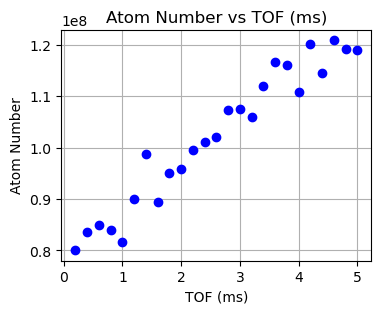

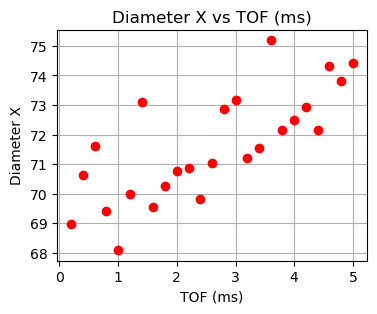

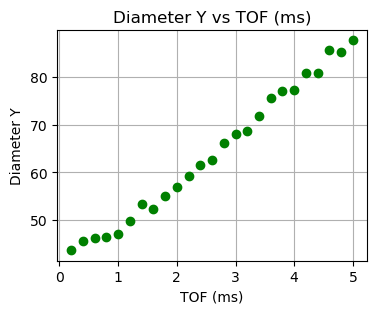

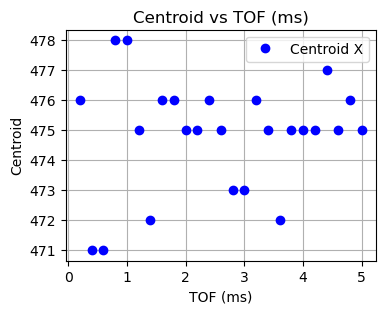

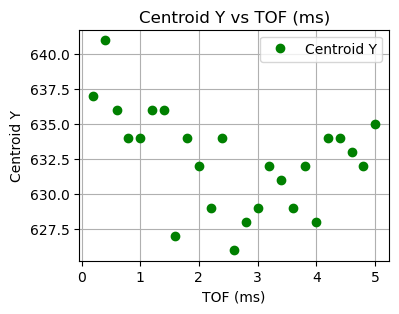

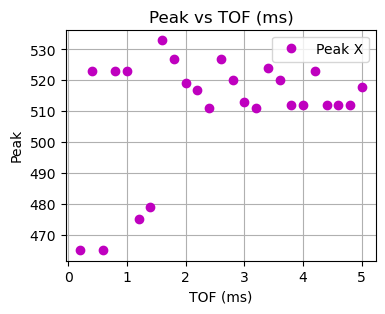

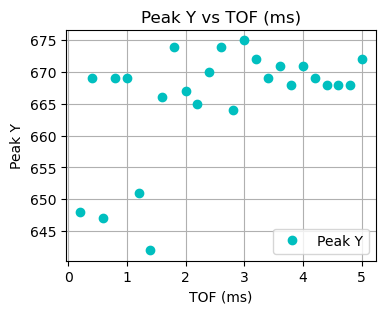

In [ ]:


#example of the data structure in the file
all = [
"ndscan.rid_6597.analysis_results",
"ndscan.rid_6597.annotations",
"ndscan.rid_6597.axes",
"ndscan.rid_6597.channels",
"ndscan.rid_6597.completed",
"ndscan.rid_6597.fragment_fqn",
"ndscan.rid_6597.ndscan_schema_revision",
"ndscan.rid_6597.online_analyses",
"ndscan.rid_6597.points.axis_0",
"ndscan.rid_6597.points.channel_atom_number",
"ndscan.rid_6597.points.channel_info",
"ndscan.rid_6597.seed",
"ndscan.rid_6597.source_id",
]


# Extracting the values and the units from the files
f1 = h5py.File(files_directory[0], "r")
print(f1)
#extract file name and run number from the file path

file_name = os.path.basename(files_directory[0])
run_number = int(file_name.split("-")[0])
c="ndscan.rid_"+str(run_number)+".points.channel_info"
d="ndscan.rid_"+str(run_number)+".points.axis_0"

a= f1["datasets"][c][()]

peakx = []
peaky = []
centroidx = []
centroidy = []
wavelength = []
atom_number = []
A = []
sx = []
sy = []
x0 = []
y0 = []


import re

for i in range(a.shape[0]):
    # decode if bytes, otherwise use as is
    if isinstance(a[i], bytes):
        decoded = a[i].decode("utf-8")
        lines = decoded.split("\n")
       
    else:
        lines = a[i]

    for line in lines:
        b = line.strip(",").split(":")
        key = b[0].strip().strip('"')
        if key == "wavelength":
            wavelength.append(float(b[1]))
        elif key == "atom_number":
            atom_number.append(float(b[1]))
        elif key == "peak":
            # extract numbers from tuple string
            tuple_str = ":".join(b[1:]).strip()
            nums = re.findall(r"[-+]?\d*\.\d+|\d+", tuple_str)
            if len(nums) >= 3:
                peakx.append(float(nums[0]))
                peaky.append(float(nums[1]))
                # If you want the third value, use float(nums[2])
            # else skip or handle error
        elif key == "centroid":
            tuple_str = ":".join(b[1:]).strip()
            nums = re.findall(r"[-+]?\d*\.\d+|\d+", tuple_str)
            if len(nums) >= 3:
                centroidx.append(float(nums[0]))
                centroidy.append(float(nums[1]))
                # If you want the third value, use float(nums[2])
        elif key == "best_values":  # Assuming this is a key for some values
            # Extract dictionary from line
            match = re.search(r"\{(.+?)\}", line)
            if match:
                dict_str = match.group(1)
                items = dict_str.split(",")
                for item in items:
                    item = item.strip()
                    if ":" in item:
                        key_part, value_part = item.split(":", 1)
                        key_item = key_part.strip().strip("'")
                        value_str = value_part.strip()
                        # Convert to float or int
                        if "." in value_str or "e" in value_str:
                            value = float(value_str)
                        else:
                            value = int(value_str)
                        # Append to the correct list
                        if key_item == "A":
                            A.append(value)
                        elif key_item == "x0":
                            x0.append(value)
                        elif key_item == "y0":
                            y0.append(value)
                        elif key_item == "sx":
                            sx.append(value)
                        elif key_item == "sy":
                            sy.append(value)
                        elif key_item == "theta":
                            if "theta" not in locals():
                                theta = []
                            theta.append(value)
                        elif key_item == "z0":
                            if "z0" not in locals():
                                z0 = []
                            z0.append(value)

# plot the atom number vs the scan parameter(TOF)
def plot_atom_number_vs_scan_param(atom_number, scan_param, d):
    """
    Plot atom number vs scan parameter from the given HDF5 file.
    """
    scan_params = f1["datasets"][d][()]

    plt.figure(figsize=(4, 3))
    plt.plot(scan_params*1e3, atom_number, marker='o', linestyle='none', color='b')
    plt.xlabel(scan_param)
    plt.ylabel("Atom Number")
    plt.title("Atom Number vs " + scan_param)
    plt.grid()
    plt.show()
plot_atom_number_vs_scan_param(atom_number, "TOF (ms)",d)


# plot the diameterx vs the scan parameter(TOF)
def plot_diameterx_vs_scan_param(diameterx, scan_param, d):
    """
    Plot diameterx vs scan parameter from the given HDF5 file.
    """
    scan_params = f1["datasets"][d][()]

    plt.figure(figsize=(4, 3))
    plt.plot(scan_params*1e3, diameterx, marker='o', linestyle='none', color='r')
    plt.xlabel(scan_param)
    plt.ylabel("Diameter X")
    plt.title("Diameter X vs " + scan_param)
    plt.grid()
    plt.show()
plot_diameterx_vs_scan_param(sx, "TOF (ms)", d)

def plot_diametery_vs_scan_param(diametery, scan_param, d):
    """
    Plot diametery vs scan parameter from the given HDF5 file.
    """
    scan_params = f1["datasets"][d][()]

    plt.figure(figsize=(4, 3))
    plt.plot(scan_params*1e3, diametery, marker='o', linestyle='none', color='g')
    plt.xlabel(scan_param)
    plt.ylabel("Diameter Y")
    plt.title("Diameter Y vs " + scan_param)
    plt.grid()
    plt.show()
plot_diametery_vs_scan_param(sy, "TOF (ms)", d)


def plot_centroid_vs_scan_param(centroidx, scan_param, d):
    """
    Plot centroid vs scan parameter from the given HDF5 file.
    """
    scan_params = f1["datasets"][d][()]

    plt.figure(figsize=(4, 3))
    plt.plot(scan_params*1e3, centroidx, marker='o', linestyle='none', color='b', label='Centroid X')
    plt.xlabel(scan_param)
    plt.ylabel("Centroid")
    plt.title("Centroid vs " + scan_param)
    plt.legend()
    plt.grid()
    plt.show()

plot_centroid_vs_scan_param(centroidx, "TOF (ms)", d)

def plot_centroidy_vs_scan_param(centroidy, scan_param, d):
    """
    Plot centroidy vs scan parameter from the given HDF5 file.
    """
    scan_params = f1["datasets"][d][()]

    plt.figure(figsize=(4, 3))
    plt.plot(scan_params*1e3, centroidy, marker='o', linestyle='none', color='g', label='Centroid Y')
    plt.xlabel(scan_param)
    plt.ylabel("Centroid Y")
    plt.title("Centroid Y vs " + scan_param)
    plt.legend()
    plt.grid()
    plt.show()
plot_centroidy_vs_scan_param(centroidy, "TOF (ms)", d)

def plot_peak_vs_scan_param(peakx, scan_param, d):
    """
    Plot peak vs scan parameter from the given HDF5 file.
    """
    scan_params = f1["datasets"][d][()]

    plt.figure(figsize=(4, 3))
    plt.plot(scan_params*1e3, peakx, marker='o', linestyle='none', color='m', label='Peak X')
    plt.xlabel(scan_param)
    plt.ylabel("Peak")
    plt.title("Peak vs " + scan_param)
    plt.legend()
    plt.grid()
    plt.show()

plot_peak_vs_scan_param(peakx, "TOF (ms)", d)

def plot_peaky_vs_scan_param(peaky, scan_param, d):

    """
    Plot peaky vs scan parameter from the given HDF5 file.
    """
    scan_params = f1["datasets"][d][()]

    plt.figure(figsize=(4, 3))
    plt.plot(scan_params*1e3, peaky, marker='o', linestyle='none', color='c', label='Peak Y')
    plt.xlabel(scan_param)
    plt.ylabel("Peak Y")
    plt.title("Peak Y vs " + scan_param)
    plt.legend()
    plt.grid()
    plt.show()
plot_peaky_vs_scan_param(peaky, "TOF (ms)", d)

def plot_centroid_position(centroidx, centroidy, d):
    """
    Plot centroid position from the given HDF5 file.
    """
    plt.figure(figsize=(4, 3))
    plt.scatter(centroidx, centroidy, marker='o', color='b')
    plt.xlabel("Centroid X")
    plt.ylabel("Centroid Y")
    plt.title("Centroid Position")
    plt.grid()
    plt.show()

